<h1 style = "color : #0EE071; text-align : center;"><em>Nata Project</em> - Feature Management Notebook</h1>
<p style = "font-size : 16px; text-align: center;">This notebook has the funcion of preparing the features for the learning model.</p>
<br>
<p style = "font-size : 12px; text-align: center;"><b>NOVA IMS</b></p>
<p style = "font-size : 10px; text-align: center;">Machine Learning I</p>
<p style = "font-size : 10px; text-align: center;">Diogo Gonçalves, João Marques, Juan Mendes, Gustavo Franco & Lucas Casimiro</p>
<br>


## <a class="anchor" id="0th-bullet">Table of Contents</a>


* [<b>1. Preparation</b>](#1st-bullet)<br>
    * [1.1 Import the needed libraries and datasets](#2nd-bullet)<br>
    * [1.2 Scaling](#4.5th-bullet)<br>
    
    
* [<b>2. Feature Selection</b>](#5th-bullet)<br>
    * [2.1 Handling Multicolinearity](#6th-bullet)<br>
    * [2.2 Filter methods](#6th-bullet)<br>
        * 2.2.1 Constant features<br>
        * 2.2.2 Spearman Correlation<br>
        * 2.2.3 Chi-Square Test<br>
    * [2.3 Wrapper Methods](#10th-bullet)<br>
        * 2.2.1 RFE<br>
    * [2.4 Embedded Methods](#12th-bullet)<br>
        * 2.3.1 Lasso Regression<br>
        * 2.3.2 Decision Tree<br>
    * [2.5 Final Insights](#15th-bullet)<br>


<hr style = "border: 3px solid #0EE071;">
<h2  style = "color : #0EE071;"> 1. Imports and Dataset Loading</h2>

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import RobustScaler

import scipy.stats as stats
from scipy.stats import chi2_contingency

from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

from sklearn.linear_model import LassoCV
from sklearn.tree import DecisionTreeClassifier

import warnings
warnings.filterwarnings("ignore")

In [34]:
X_train = pd.read_pickle('Nata_files/data_clean/X_train_clean.pkl')
X_test = pd.read_pickle('Nata_files/data_clean/X_test_clean.pkl')
y_train = pd.read_pickle('Nata_files/data_clean/y_train_clean.pkl')
y_test = pd.read_pickle('Nata_files/data_clean/y_test_clean.pkl')

<hr style = "border: 3px solid #0EE071;">
<h2  style = "color : #0EE071;"> 2. Feature Scaling</h2>
<p style = "font-size : 15px;">To optimize our model, we must address the different scales and distributions of our data. In this section, we'll apply Robust Scaling. This prevents features with larger magnitudes from dominating the model's learning process.</p>

In [35]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4157 entries, 893 to 4904
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ambient_humidity   4157 non-null   float64
 1   baking_duration    4157 non-null   float64
 2   cooling_period     4157 non-null   float64
 3   cream_fat_content  4157 non-null   float64
 4   egg_temperature    4157 non-null   float64
 5   egg_yolk_count     4157 non-null   float64
 6   final_temperature  4157 non-null   float64
 7   lemon_zest_ph      4157 non-null   float64
 8   oven_temperature   4157 non-null   float64
 9   preheating_time    4157 non-null   float64
 10  salt_ratio         4157 non-null   float64
 11  sugar_content      4157 non-null   float64
 12  vanilla_extract    4157 non-null   float64
 13  origin_porto       4157 non-null   float64
dtypes: float64(14)
memory usage: 487.1 KB


The dataset has no categorical variables, so there's no need to isolate numerical features

In [36]:
# Defining the scaler
scaler = RobustScaler()

# Fitting only the training data and transforming both 
X_train_scl = scaler.fit_transform(X_train)
X_train_scl = pd.DataFrame(X_train_scl, columns=X_train.columns)

X_test_scl = scaler.transform(X_test)
X_test_scl = pd.DataFrame(X_test_scl, columns=X_test.columns)

X_train_scl

,ambient_humidity,baking_duration,cooling_period,cream_fat_content,egg_temperature,egg_yolk_count,final_temperature,lemon_zest_ph,oven_temperature,preheating_time,salt_ratio,sugar_content,vanilla_extract,origin_porto
0,0.45,1.444444,0.000000,0.000000,0.107143,0.0,-0.643478,0.0,-0.720721,2.575,2.031878,0.059524,0.764706,1.0
1,0.75,-0.444444,-0.285714,-0.333333,0.000000,0.0,0.478261,-0.5,0.369369,0.400,0.469629,0.000000,-1.117647,0.0
2,-0.65,0.444444,-0.142857,0.666667,1.107143,4.0,-0.243478,0.0,-0.144144,-0.200,-0.603163,0.071429,0.294118,0.0
3,0.05,0.444444,0.428571,0.200000,-0.785714,2.0,-0.556522,0.5,-0.495495,-1.400,-0.884287,-1.107143,-0.705882,0.0
4,0.80,1.666667,-1.071429,0.000000,-0.928571,-1.0,-0.556522,0.0,-0.603604,0.825,1.354167,0.142857,-0.294118,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4152,0.10,0.666667,-2.214286,-0.333333,0.785714,1.0,-0.400000,0.0,-0.414414,-0.600,0.885793,-0.714286,1.000000,0.0
4153,0.90,-0.888889,0.071429,-0.400000,0.000000,-1.0,0.426087,0.5,0.468468,0.275,0.371235,-1.000000,1.588235,0.0
4154,0.35,1.222222,-0.500000,-0.866667,-0.785714,0.0,0.365217,-1.0,0.423423,0.600,-0.970633,-0.250000,-1.000000,0.0
4155,0.80,0.777778,0.642857,0.600000,0.500000,-1.0,0.913043,-0.5,0.900901,-0.200,0.767821,6.047619,-0.352941,0.0


<hr style = "border: 3px solid #0EE071;">
<h2  style = "color : #0EE071;"> 2. Feature Selection</h2>

<h3 style="color: #0EE071;">2.1 Handling Multicolinearity</h3>


As seen in the correlation heatmap in NB1, we see 'oven_temperature' and 'final_temperature' have an extremely high correlation, which means having both is redundant, so we will check for their correlation with the target variable and make a decision to drop the one with the lowest value before getting into the filter methods.

In [24]:
# Correlation analysis before dropping features
analysis_corr = pd.DataFrame(X_train_scl, columns=X_train.columns)[['oven_temperature', 'final_temperature']].copy()
analysis_corr['quality_class'] = y_train.values

corr_oven = analysis_corr['oven_temperature'].corr(analysis_corr['quality_class'])
corr_final = analysis_corr['final_temperature'].corr(analysis_corr['quality_class'])

print(f"Correlation (Oven Temp vs Target): {corr_oven}")
print(f"Correlation (Final Temp vs Target): {corr_final}")


Correlation (Oven Temp vs Target): -0.043876851948513707
Correlation (Final Temp vs Target): -0.04347796497722893


We conclude that the 'final_temperature' column has a higher absolute correlation, which means it has a better chance of helping to predict the target variable. So, we will drop 'oven_temperature'.

In [25]:
X_train.drop('oven_temperature', axis=1, inplace=True)
X_test.drop('oven_temperature', axis=1, inplace=True)

X_train_scl.drop('oven_temperature', axis=1, inplace=True)
X_test_scl.drop('oven_temperature', axis=1, inplace=True)

<h3 style="color: #0EE071;">2.2 Filter methods</h3>

### 2.2.1 Constant Features

In [26]:
X_train_scl.var().sort_values()

origin_porto         0.179064
ambient_humidity     0.334618
final_temperature    0.499391
egg_temperature      0.531204
vanilla_extract      0.671034
lemon_zest_ph        0.678345
salt_ratio           0.743294
baking_duration      0.792154
cream_fat_content    0.795610
preheating_time      0.879926
cooling_period       1.023423
egg_yolk_count       1.584989
sugar_content        3.278659
dtype: float64

We conclude that all variables in the dataset exhibit non-zero variance, indicating diversity and variability in their values, so no measures need to be taken.

### 2.1.2. Spearman Correlation

We will now examine the Spearman correlation between variables.  To facilitate this analysis, a new dataframe has been created using all the training data, including the dependent variable. This inclusion allows us to investigate whether any of the independent variables exhibit correlations with the target variable. 



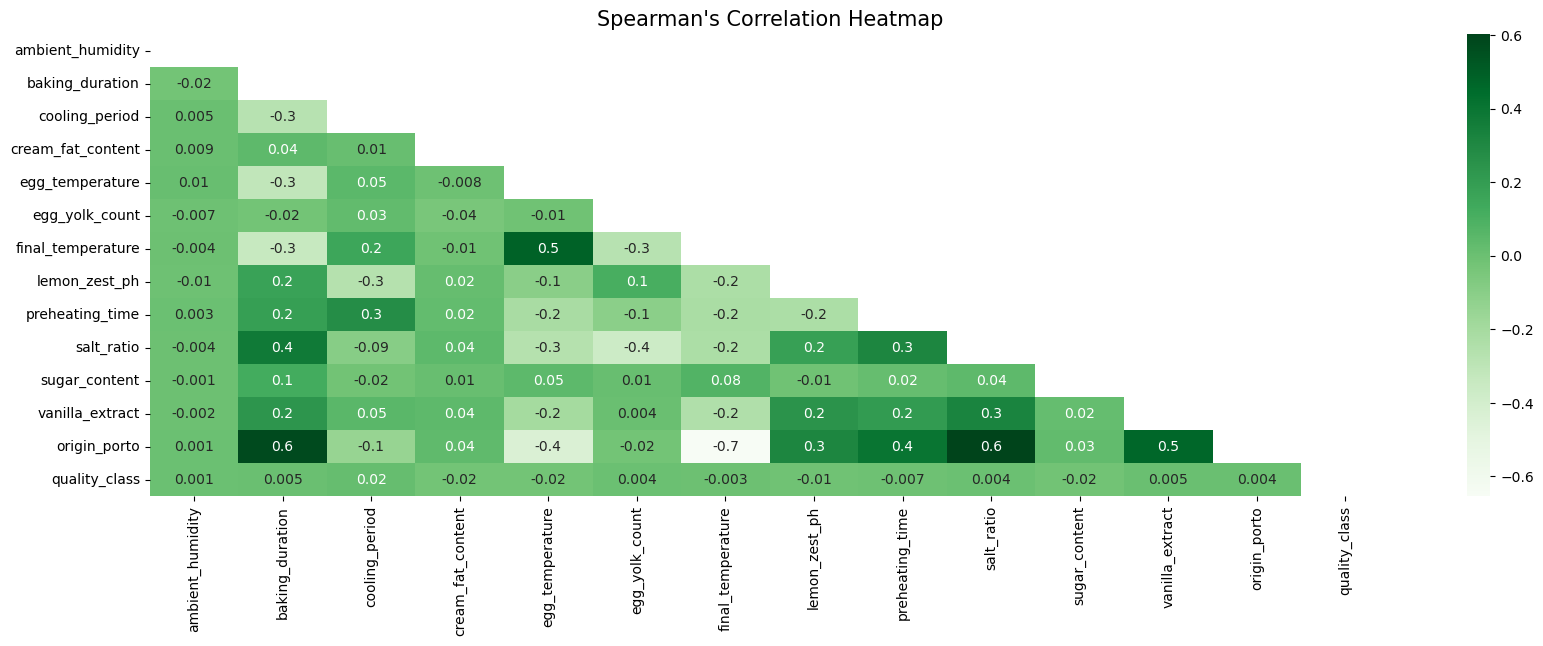

In [ ]:
# Joining numerical features and target for correlation analysis
all_train = X_train_scl.join(y_train)

# Computing Spearman's Correlation
correlation = all_train.corr(method = 'spearman')

# Plotting the lower triangle of the correlation map
def corr_heatmap(correlation):
    plt.figure(figsize=(20, 6))
    ax = sns.heatmap(data = correlation, annot = True, mask = np.triu(np.ones_like(correlation)), cmap = 'Greens', fmt = '.1')
    ax.set_title("Spearman's Correlation Heatmap", fontdict = {'fontsize': 15})
    plt.show()

corr_heatmap(correlation)

We conclude that there are no indendent variables highly correlated with the target variable. However, there is a significant and subtle correlation between 'final_temperature' and 'egg_temperature', which makes logical sense.

Given the absence of strong correlations, it's essential to apply other feature selection methods to gain deeper insights from the dataset.

<h3 style="color: #0EE071;">2.3 Wrapper methods</h3>

In this section we will apply a wrapper method for feature selection. These aim to identify the most impactful subset of features by training different predictive models with varying feature combinations and comparing their performances. We will start by initializing our model.



In [38]:
model = RandomForestClassifier()

### 2.3.1 RFE

Recursive Feature Elimination will help selecting the most important features to keep.

In [39]:
# Number of features
nof_list = np.arange(1,15)
high_score = 0

# Variable to store the optimum features
nof = 0
score_list = []
for n in range(len(nof_list)):
    rfe = RFE(model,n_features_to_select = nof_list[n])
    X_train_rfe = rfe.fit_transform(X_train_scl,y_train)
    X_test_rfe = rfe.transform(X_test_scl)
    model.fit(X_train_rfe,y_train)

    score = model.score(X_test_rfe,y_test)
    score_list.append(score)

    if(score > high_score):
        high_score = score
        nof = nof_list[n]

print("Optimum number of features: %d" %nof)
print("Score with %d features: %f" % (nof, high_score))

Optimum number of features: 10
Score with 10 features: 0.788462


The optimum number of features for this method is 5. So, 5 features will be selected by the RFE model.

In [40]:
rfe = RFE(estimator = model, n_features_to_select = nof)
rfe.fit_transform(X_train_scl, y_train)
selected_features = pd.Series(rfe.support_, index = X_train_scl.columns)
print(f"Features to keep:\n{selected_features}")

Features to keep:
ambient_humidity     False
baking_duration       True
cooling_period        True
cream_fat_content    False
egg_temperature       True
egg_yolk_count        True
final_temperature     True
lemon_zest_ph        False
oven_temperature      True
preheating_time       True
salt_ratio            True
sugar_content         True
vanilla_extract       True
origin_porto         False
dtype: bool


<h3 style="color: #0EE071;">2.4 Embedded methods</h3>

We also used Embedded Methods. This technique involves selecting features during the training of predictive models, taking into account their importance.

### 2.4.1 Lasso Regression

The following function was taken from the Machine Learning classes and serves the purpose of constructing a visualization for the feature importance.

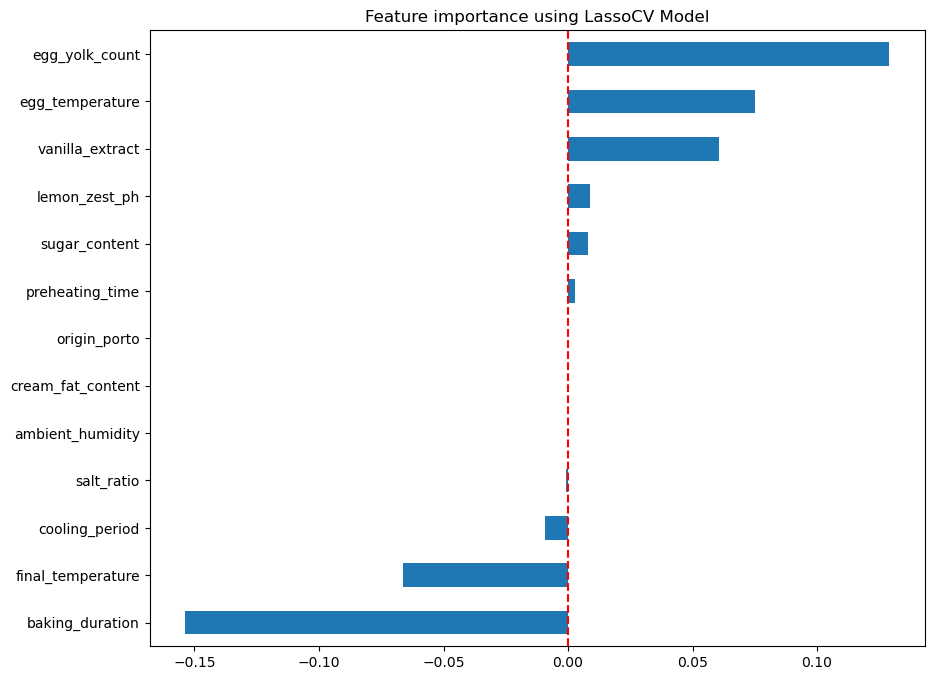

In [32]:
def plot_importance(coef,name):
    imp_coef = coef.sort_values()
    plt.figure(figsize=(10,8))
    imp_coef.plot(kind = "barh")
    plt.title("Feature importance using " + name + " Model")
    plt.axvline(x=0, color='red', linestyle='--')
    plt.show()

reg = LassoCV()
reg.fit(X_train_scl, y_train)
coef = pd.Series(reg.coef_, index = X_train_scl.columns)
plot_importance(coef, 'LassoCV')

According to the Lasso Regression, we should discard the 'cream_fat_content', 'ambient_humidity' and 'origin_porto' columns, as they seem insignificant for the definition of the target when compared to the other variables. 'salt_ratio' and 'preheating time' are also on the verge of being discardable by this method.

### 2.4.2 Decision tree

While Lasso Regression is great for eliminating features with no linear correlation with the target, it may incorrectly discard features that are useful only in non-linear thresholds or specific combinations. 

For this, we will use a Decision Tree, to address potential ties and limit ambiguity.

Text(0.5, 1.0, 'Feature Importance using Decision Tree Classifier')

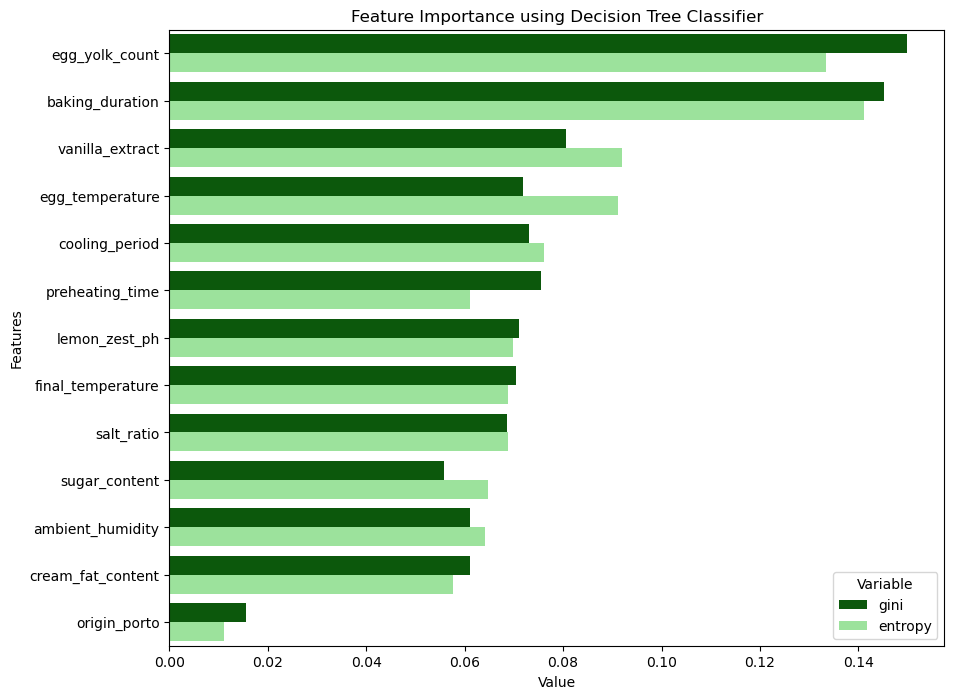

In [33]:
gini_importance = DecisionTreeClassifier(splitter='random', random_state=42).fit(X_train_scl, y_train).feature_importances_
entropy_importance = DecisionTreeClassifier(criterion='entropy', splitter='random', random_state=42).fit(X_train_scl, y_train).feature_importances_

zippy = pd.DataFrame(zip(gini_importance, entropy_importance), columns=['gini', 'entropy'])
zippy['Features'] = X_train_scl.columns
tidy = zippy.melt(id_vars='Features').rename(columns=str.title)
tidy.sort_values(['Value'], ascending=False, inplace=True)

plt.figure(figsize=(10, 8))
sns.barplot(y='Features', x='Value', hue='Variable', data=tidy, palette=['darkgreen', 'lightgreen'])
plt.title("Feature Importance using Decision Tree Classifier")

The columns 'cream_fat_content' and 'ambient_humidity' remain clearly as 2 of the 3 least influential features, joined by 'lemon_zest_ph', which did have a noticeable presence in the LassoCV model, yet is the least valuable from this method.

Also, we have a high disparity between entropy and gini impurity in the 'final_temperature' and 'preheating_time'. Despite both being relevant for the prediction and probably none of them is being removed, we need to understand this difference. 

Entropy's preference for final_temperature indicates that this attribute likely offers substantial "Information Gain" by effectively distinguishing a certain, probably less common, outcome that gini does not emphasize as significantly. 

'preheating_time', on the other hand, appears to function as a strong binary threshold rather than a complex spectrum, as indicated by its higher Gini importance. Gini Impurity favors preheating_time because it is likely to create a OK/KO boundary (e.g., if preheating time is too short, the batch fails).

<h3 style="color: #0EE071;">2.5 Final Insights</h3>

| Numerical Data |  Spearman's Correlation | RFE | Lasso | Decision Tree | Relevance |
| --- | --- | --- | --- | --- | --- 
|  ambient_humidity | Discard |  Discard | Discard | Discard? | **Discard** |
|  baking_duration | Discard |  Keep  | Keep | Keep | **Keep** |
|  cooling_period | Discard  |  Keep |  Keep | Keep | **Keep** |
|  cream_fat_content | Discard  |  Discard |  Discard | Discard? | **Discard** |
|  egg_temperature  | Discard |  Keep | Keep | Keep | **Keep** |
|  egg_yolk_count  | Discard |  Keep |  Keep | Keep | **Keep** |
|  final_temperature  | Discard |  Keep | Keep | Keep | **Keep** |
|  lemon_zest_ph  | Discard |  Discard | Keep | Keep | **Keep*** |
|  preheating_time  | Discard |  Keep |  Keep | Keep | **Keep** |
|  salt_ratio  | Discard |  Keep |  Discard? | Keep | **Keep*** |
|  sugar_content  | Discard |  Keep | Keep | Discard? | **Keep*** |
|  vanilla_extract  | Discard |  Keep | Keep | Keep | **Keep** |
|  origin_porto  | Discard |  Discard | Discard | Discard | **Keep** |

<br>


*Given the tie in keeps and discards for these features, we decided to keep them. The decision tree was unsure on 'sugar_content', but other methods suggested to keep. The Lasso regression was unsure on 'salt_ratio', and the RFE suggested to discard 'lemon_zest_ph', but as our goal is to build a classifier, we decided the decision tree would outweight both these linear methods' decision.

In [41]:
cols_to_drop = ['ambient_humidity', 'cream_fat_content','origin_porto']

# Dropping less important features on X_train and X_test 
X_train_final = X_train_scl.drop(cols_to_drop, axis=1)
X_test_final = X_test_scl.drop(cols_to_drop, axis=1)

# Checking the final datasets
display(X_train_final.head())
display(X_test_final.head())

,baking_duration,cooling_period,egg_temperature,egg_yolk_count,final_temperature,lemon_zest_ph,oven_temperature,preheating_time,salt_ratio,sugar_content,vanilla_extract
0,1.444444,0.000000,0.107143,0.0,-0.643478,0.0,-0.720721,2.575,2.031878,0.059524,0.764706
1,-0.444444,-0.285714,0.000000,0.0,0.478261,-0.5,0.369369,0.400,0.469629,0.000000,-1.117647
2,0.444444,-0.142857,1.107143,4.0,-0.243478,0.0,-0.144144,-0.200,-0.603163,0.071429,0.294118
3,0.444444,0.428571,-0.785714,2.0,-0.556522,0.5,-0.495495,-1.400,-0.884287,-1.107143,-0.705882
4,1.666667,-1.071429,-0.928571,-1.0,-0.556522,0.0,-0.603604,0.825,1.354167,0.142857,-0.294118


,baking_duration,cooling_period,egg_temperature,egg_yolk_count,final_temperature,lemon_zest_ph,oven_temperature,preheating_time,salt_ratio,sugar_content,vanilla_extract
0,1.000000,1.928571,0.000000,-1.0,0.000000,-0.5,0.000000,0.050,1.754267,0.000000,-0.529412
1,0.000000,1.714286,0.000000,-1.0,1.400000,-1.5,0.000000,0.450,0.409890,0.000000,0.235294
2,-0.111111,0.428571,0.000000,0.0,1.356522,0.0,1.324324,-0.375,0.104669,0.000000,-0.294118
3,-0.333333,0.214286,1.357143,2.0,-0.034783,1.0,-0.126126,-0.600,-0.319026,0.214286,-0.352941
4,0.888889,-2.214286,0.035714,1.0,-0.991304,1.5,-0.990991,-0.725,1.512801,-0.285714,0.176471


Now, our datasets are ready for modeling.

In [ ]:
# Saving the final datasets
# X_train_final.to_pickle('Nata_files/data_clean/X_train_final.pkl')
# X_test_final.to_pickle('Nata_files/data_clean/X_test_final.pkl')  